In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
sys.path.insert(0, Path("./").absolute().as_posix())

In [1]:
from masterplanenergydemand.config import *
from masterplanenergydemand.util import *
from masterplanenergydemand.enums import *
from masterplanenergydemand.fabric import Fabric
from masterplanenergydemand.form import Form
from masterplanenergydemand.mped import Masterplan
from masterplanenergydemand.program import Program
from masterplanenergydemand.system import System
from masterplanenergydemand.typology import Typology
from masterplanenergydemand.mped import Masterplan

from ladybug.epw import EPW

# globals
epw_file = r"C:\Users\tgerrish\Documents\GitHub\BHoM\LadyBugTools_Prototypes\LadyBugTools_Prototype_Engine\Python\MasterplanEnergyDemand\masterplanenergydemand\test\test.epw"
epw = EPW(epw_file)

excel_file = r"C:\Users\tgerrish\Documents\GitHub\BHoM\LadyBugTools_Prototypes\LadyBugTools_Prototype_Engine\Python\MasterplanEnergyDemand\masterplanenergydemand\test\test.xlsx"

honeybee - INFO - Successfully imported Honeybee plugin: honeybee_display
honeybee - INFO - Successfully imported Honeybee plugin: honeybee_doe2
honeybee - INFO - Successfully imported Honeybee plugin: honeybee_energy
honeybee - INFO - Successfully imported Honeybee plugin: honeybee_idaice
honeybee - INFO - Successfully imported Honeybee plugin: honeybee_ies
honeybee - INFO - Successfully imported Honeybee plugin: honeybee_radiance
honeybee - INFO - Successfully imported Honeybee plugin: honeybee_schema
honeybee - INFO - Successfully imported Honeybee plugin: honeybee_standards
honeybee - INFO - Successfully imported Honeybee plugin: honeybee_vtk
honeybee_energy - INFO - Successfully imported Honeybee-energy plugin: honeybee_energy_standards


In [4]:
# and now for something completely different
excel_file = r"C:\Users\tgerrish\Buro Happold\P055843 P-Dubai Expo City Masterplan - UNS - 05_Teams Files\Sustainability and climate\Energy\20240627_ExpoCity_Dataset.xlsx"
sheet_name = "ECD_Baseline"

mped = Masterplan.from_excel(excel_file=excel_file, sheet_name=sheet_name)

masterplanenergydemand - INFO - BuildingType.ACCOMODATION_HOUSE_LOWRISE currently using BuildingType.ACCOMODATION_APARTMENT_MIDRISE default program.
masterplanenergydemand - INFO - occupant_density is null. Setting to 0.025024895751482725.
masterplanenergydemand - INFO - lighting_power_density is null. Setting to 8.834520116022999.
masterplanenergydemand - INFO - equipment_power_density is null. Setting to 6.009003854816946.
masterplanenergydemand - INFO - ventilation_rate is null. Setting to 0.0.
masterplanenergydemand - INFO - heating_setpoint is null. Setting to 21.6831082.
masterplanenergydemand - INFO - heating_setback is null. Setting to 21.5282667.
masterplanenergydemand - INFO - cooling_setpoint is null. Setting to 24.3859235.
masterplanenergydemand - INFO - cooling_setback is null. Setting to 24.540765.
masterplanenergydemand - INFO - BuildingType.ACCOMODATION_HOUSE_LOWRISE currently using BuildingType.ACCOMODATION_APARTMENT_MIDRISE default program.
masterplanenergydemand - IN

In [5]:
# df_res = mped.results()
df_ec = mped.energy_consumption()

masterplanenergydemand - INFO - BuildingType.ACCOMODATION_HOUSE_LOWRISE currently using BuildingType.ACCOMODATION_APARTMENT_MIDRISE default program.
masterplanenergydemand - INFO - Form(0x15648a0f1f0) - Calculating building height
masterplanenergydemand - INFO - BuildingType.ACCOMODATION_HOUSE_LOWRISE currently using BuildingType.ACCOMODATION_APARTMENT_MIDRISE default program.
masterplanenergydemand - INFO - Form(0x15648646980) - Calculating building height
masterplanenergydemand - INFO - Form(0x15648644040) - Calculating building height
masterplanenergydemand - INFO - Form(0x156486469e0) - Calculating building height
masterplanenergydemand - INFO - Form(0x15648647df0) - Calculating building height
masterplanenergydemand - INFO - Form(0x15648665e10) - Calculating building height
masterplanenergydemand - INFO - Form(0x156483360b0) - Calculating building height
masterplanenergydemand - INFO - Form(0x156488241f0) - Calculating building height
masterplanenergydemand - INFO - Form(0x1564833

In [27]:
df_ec.filter(regex="Lifts").loc["2017-06"].sum().droplevel(1) / pd.Series(mped.gfa_table)

AttachedTownhouse    0.002360
AttachedVilla        0.002563
Apartments           0.000428
Retail               0.014722
Office               0.006618
FoodAndBeverage      0.000000
LightIndustry        0.182104
Agriculture          1.981443
FuelStation          2.109024
Hotel                0.002893
Education            0.134396
Mosque               0.606300
Healthcare           0.173815
PublicFacility       0.080464
Cultural             0.427925
Sports               1.374212
DataCenter           0.000000
DistrictCooling      0.291080
Electrical           0.292791
Utilities            0.147426
dtype: float64

In [22]:
# NOTES - check the EUI for each typology - create a method which does this fo the year to sense check things against a common metric!
# Chekc the occupant dnesity for the accomodation typologies


AttachedTownhouse    135433.570267
AttachedVilla        105944.200539
Apartments           986455.213461
Retail               213017.865850
Office               323451.715998
FoodAndBeverage      116916.477486
LightIndustry         13402.110472
Agriculture            1231.718400
FuelStation            1157.208304
Hotel                114831.705425
Education             21354.181545
Mosque                 4062.000000
Healthcare            13980.211952
PublicFacility        30624.366480
Cultural               8757.713244
Sports                 3718.000000
DataCenter            10867.820454
DistrictCooling        8384.552845
Electrical             8335.560344
Utilities             16554.647718
dtype: float64

<Axes: >

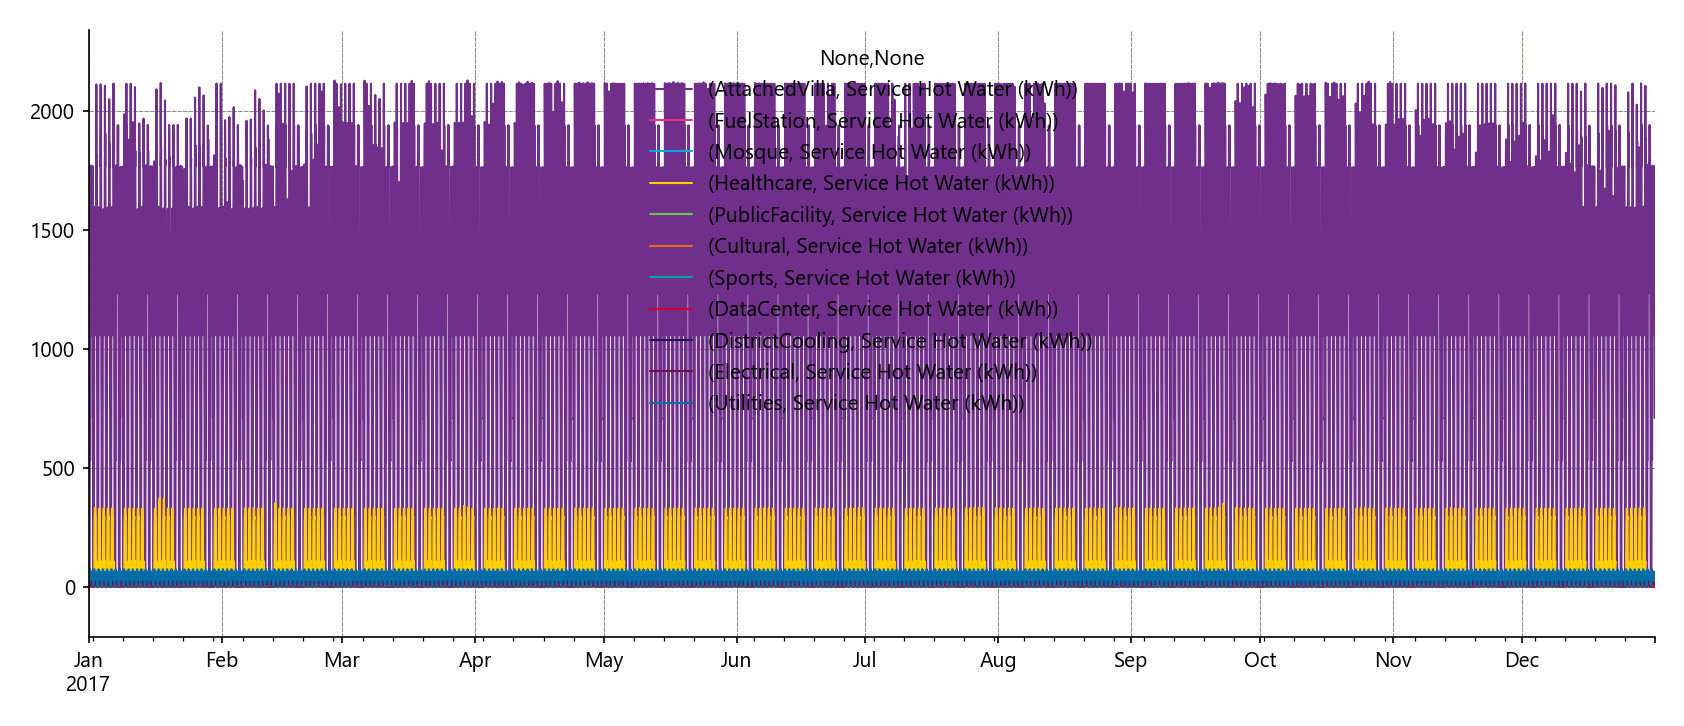

In [83]:
df_res.filter(regex="Water Use Equipment Zone Sensible Heat Gain Energy Intensity")
df_res.filter(regex="Service Hot Water").plot()

In [74]:
for i in range(12):
    a = pd.concat([
        df.filter(regex="Hot Water").filter(regex="calc").iloc[:, i],
        df.filter(regex="Hot Water").filter(regex="eplus").iloc[:, i],
    ], axis=1).sum()
    print(a)

AttachedTownhouse  Hot Water (kWh) calc     0.0
                   Hot Water (kWh) eplus    0.0
dtype: float64
AttachedVilla  Hot Water (kWh) calc     0.0
               Hot Water (kWh) eplus    0.0
dtype: float64
Apartments  Hot Water (kWh) calc     0.0
            Hot Water (kWh) eplus    0.0
dtype: float64
Retail  Hot Water (kWh) calc     0.0
        Hot Water (kWh) eplus    0.0
dtype: float64
Office  Hot Water (kWh) calc     0.0
        Hot Water (kWh) eplus    0.0
dtype: float64
FoodAndBeverage  Hot Water (kWh) calc     0.0
                 Hot Water (kWh) eplus    0.0
dtype: float64
LightIndustry  Hot Water (kWh) calc     0.0
               Hot Water (kWh) eplus    0.0
dtype: float64
Agriculture  Hot Water (kWh) calc     0.0
             Hot Water (kWh) eplus    0.0
dtype: float64
FuelStation  Hot Water (kWh) calc     0.0
             Hot Water (kWh) eplus    0.0
dtype: float64
Hotel  Hot Water (kWh) calc     0.0
       Hot Water (kWh) eplus    0.0
dtype: float64
Education  Hot W

masterplanenergydemand - INFO - BuildingType.ACCOMODATION_HOUSE_LOWRISE currently using BuildingType.ACCOMODATION_APARTMENT_MIDRISE default program.
masterplanenergydemand - INFO - BuildingType.ACCOMODATION_HOUSE_LOWRISE currently using BuildingType.ACCOMODATION_APARTMENT_MIDRISE default program.
masterplanenergydemand - INFO - BuildingType.ACCOMODATION_HOUSE_LOWRISE currently using BuildingType.ACCOMODATION_APARTMENT_MIDRISE default program.
masterplanenergydemand - INFO - BuildingType.ACCOMODATION_HOUSE_LOWRISE currently using BuildingType.ACCOMODATION_APARTMENT_MIDRISE default program.


<Axes: >

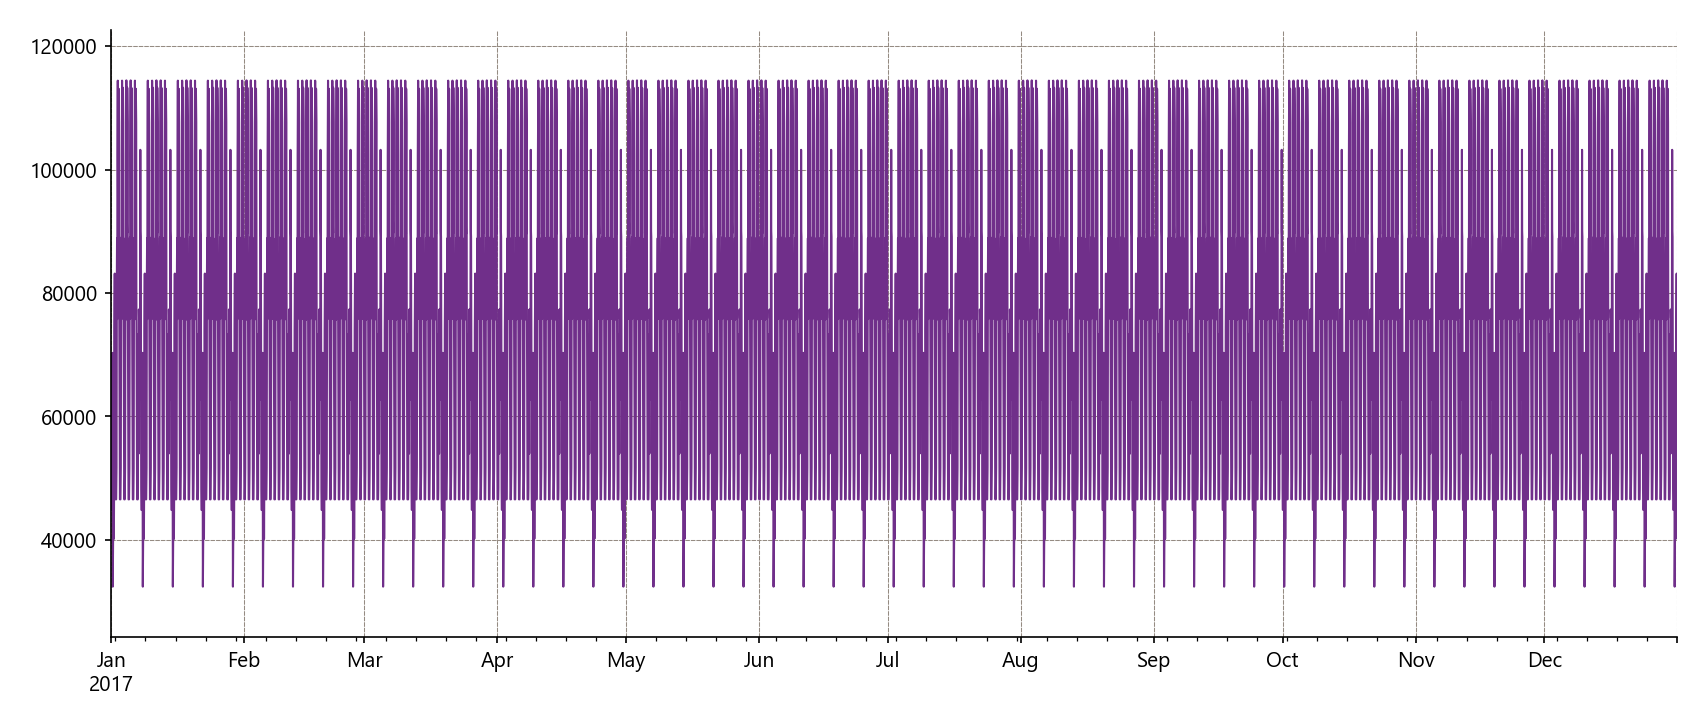

In [61]:
x = mped.population().sum(axis=1)
# x.groupby(x.index.hour).mean().plot()
x.plot()

In [138]:
building_type = BuildingType.ACCOMODATION_APARTMENT_HIGHRISE
vintage = Vintage.ASHRAE_901_2004

# get property
ashrae_climate = int(epw.ashrae_climate_zone[0])
from masterplanenergydemand.enums import EconomizerType
list(EconomizerType)
EconomizerType[df[(df.building_type == building_type.name) & (df.vintage == vintage.name) & (df.ashrae_climate == ashrae_climate)].economizer_type.values[0]]

<EconomizerType.DIFFERENTIAL_DRY_BULB: 'DifferentialDryBulb'>

In [37]:
# test from building type

bt = BuildingType.COMMERCIAL_OFFICE_LARGE

# x = Fabric.from_building_type(bt, epw=epw, vintage=Vintage.ASHRAE_901_2007)
# x.constructions()

# x = Form.from_building_type(bt)
# x.base_model()

x = 

masterplanenergydemand - INFO - Creating default Form for BuildingType.COMMERCIAL_OFFICE_LARGE
masterplanenergydemand - INFO - Using default rotation of 0
masterplanenergydemand - INFO - Using default terrain of TerrainType.URBAN
masterplanenergydemand - INFO - Form(0x2180c2d8670) - Creating base model
masterplanenergydemand - INFO - Form(0x2180c2d8670) - Calculating building height
masterplanenergydemand - INFO - Form(0x2180c2d8670) - Creating footprint


Model: base_model

In [4]:
# run the test excel file to debug and generate results
mped = Masterplan.from_excel(excel_file, "TestMPED")

masterplanenergydemand - WARNING - lighting_power_density is null. Setting to 0.
masterplanenergydemand - WARNING - infiltration_rate is null. Setting to 0.0006.
masterplanenergydemand - WARNING - ventilation_rate is null. Setting to 0.
masterplanenergydemand - WARNING - ventilation_rate is null. Setting to 0.


In [112]:
# create some typologies to start summarising, and sense checking

Typology(
    identifier="Test1",
    building_type=BuildingType.CIVIC_COURTHOUSE, 
    total_area=1000, 
    vintage=Vintage.ASHRAE_901_2019,
    fabric=Fabric(
        wall_u_value=[1] * 8,
        wall_sri=55,
        floor_u_value=0.5,
        roof_u_value=0.75,
        window_u_value=[0.99] * 8,
        window_shgc=[0.5] * 8,
        skylight_u_value=0.99,
        skylight_shgc=0.3,
        roof_sri=60,
    ), 
    form=Form(
        average_footprint_area=100,
        average_num_floors=2,
        average_floor_height=3.5,
        rotation=0,
        terrain=TerrainType.URBAN,
        glazing_ratio=[0.25, 0.1, 0.25, 0.4, 0.3, 0.2, 0.1, 0],
        skylight_ratio=0.0,
    ), 
    program=Program.from_building_type(building_type=BuildingType.COMMERCIAL_OFFICE_LARGE, 
    system=System(), 
)

KeyError: 'heating_setpoint'

In [105]:
Masterplan.random(seed=1) == Masterplan.random()

# mped.simulation_directory
# df = mped.results()

masterplanenergydemand - INFO - Creating random masterplan with 5 typologies. NOTE: Each typology will be random if a seed is given as duplicate typologies cannot exist in the same masterplan.
masterplanenergydemand - INFO - Creating random masterplan with 5 typologies. NOTE: Each typology will be random if a seed is given as duplicate typologies cannot exist in the same masterplan.


False

In [90]:
import numpy as np

length  = 8
alpha_num = list('abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789')
np_codes = "".join(np.random.choice(alpha_num, size=length))
np_codes


'524132'

In [32]:
typ_0, typ_1 = df.iloc[:, df.columns.get_level_values(1) == "People (kWh)"].mean().values

# df.columns.get_level_values(1) == "People (kWh)"

array([    0.        , 19114.87040193])

In [13]:
df = mped.energy_consumption()
# df = mped.results()

In [14]:
df

TestTypology1                               \
                    Cooling (kWh) Heating (kWh) Lighting (kWh)   
2017-01-01 00:00:00      5.571546     35.983367            0.0   
2017-01-01 01:00:00      6.979149     49.938198            0.0   
2017-01-01 02:00:00      4.506922     54.993815            0.0   
2017-01-01 03:00:00      2.967358     59.224267            0.0   
2017-01-01 04:00:00      1.929544     61.065657            0.0   
...                           ...           ...            ...   
2017-12-31 19:00:00      0.014767     31.879960            0.0   
2017-12-31 20:00:00      0.145775     33.173380            0.0   
2017-12-31 21:00:00      0.367917     34.752673            0.0   
2017-12-31 22:00:00      0.658239     36.459394            0.0   
2017-12-31 23:00:00      1.100973     39.557288            0.0   

                                                                    \
                    Electric Equipment (kWh) Hot Water (kWh) eplus   
2017-01-01 00:00:00                      0.0                   0.0   
2017-01-01 01:00:00                      0.0                   0.0   
2017-01-01 02:00:00                      0.0                   0.0   
2017-01-01 03:00:00                      0.0                   0.0   
2017-01-01 04:00:00                      0.0                   0.0   
...                                      ...                   ...   
2017-12-31 19:00:00                      0.0                   0.0   
2017-12-31 20:00:00                      0.0                   0.0   
2017-12-31 21:00:00                      0.0                   0.0   
2017-12-31 22:00:00                      0.0                   0.0   
2017-12-31 23:00:00                      0.0                   0.0   

                                                                        \
                    Hot Water (kWh) calc Lifts (kWh) Pumps (kWh) eplus   
2017-01-01 00:00:00                  0.0         0.0               0.0   
2017-01-01 01:00:00                  0.0         0.0               0.0   
2017-01-01 02:00:00                  0.0         0.0               0.0   
2017-01-01 03:00:00                  0.0         0.0               0.0   
2017-01-01 04:00:00                  0.0         0.0               0.0   
...                                  ...         ...               ...   
2017-12-31 19:00:00                  0.0         0.0               0.0   
2017-12-31 20:00:00                  0.0         0.0               0.0   
2017-12-31 21:00:00                  0.0         0.0               0.0   
2017-12-31 22:00:00                  0.0         0.0               0.0   
2017-12-31 23:00:00                  0.0         0.0               0.0   

                                                 ...  TestTypology3  \
                    Pumps (kWh) calc Fans (kWh)  ...  Cooling (kWh)   
2017-01-01 00:00:00     2.721349e-08   2.316426  ...  258974.301970   
2017-01-01 01:00:00     3.408874e-08   2.293215  ...  255963.079990   
2017-01-01 02:00:00     2.201347e-08   2.291489  ...  255828.773530   
2017-01-01 03:00:00     1.449368e-08   2.290476  ...  255946.216379   
2017-01-01 04:00:00     9.424606e-09   2.289213  ...  256110.844104   
...                              ...        ...  ...            ...   
2017-12-31 19:00:00     7.212922e-11   2.279163  ...  220995.398949   
2017-12-31 20:00:00     7.120170e-10   2.280515  ...  222045.671782   
2017-12-31 21:00:00     1.797042e-09   2.282706  ...  254730.310876   
2017-12-31 22:00:00     3.215085e-09   2.283439  ...  256398.486957   
2017-12-31 23:00:00     5.377562e-09   2.285671  ...  256466.942376   

                                                                           \
                    Heating (kWh) Lighting (kWh) Electric Equipment (kWh)   
2017-01-01 00:00:00           0.0            0.0                20.193133   
2017-01-01 01:00:00           0.0            0.0                18.447567   
2017-01-01 02:00:00           0.0            0.0       

In [8]:
df.filter(regex="Water").sum()#.plot()

TestTypology2  Service Hot Water (kWh)                                               1.108517e+05
               Water Use Equipment Zone Sensible Heat Gain Energy Intensity (kWh)    2.828132e+04
               Water Use Equipment Heating Rate Intensity (W)                        1.717054e+08
               Water Heater Electricity Energy Intensity (kWh)                       1.868677e+05
               Water Use Equipment Heating Energy Intensity (kWh)                    1.717054e+05
               Water Use Equipment Zone Latent Gain Energy Intensity (kWh)           1.108517e+05
               Water Use Equipment Hot Water Volume (m3)                             3.907893e+02
TestTypology3  Service Hot Water (kWh)                                               5.067796e+05
               Water Use Equipment Heating Energy Intensity (kWh)                    7.886046e+05
               Water Use Equipment Heating Rate Intensity (W)                        7.886046e+08
               Water

In [7]:
typologies = [Typology.random() for i in range(2)]

In [18]:
df = pd.read_excel(excel_file, sheet_name="INPUTS", engine="openpyxl", header=None, index_col=0)

In [29]:
d = df[3].to_dict()
# Typology.parse_obj_extended(d)
Program.parse_obj(d)

masterplanenergydemand - INFO - Lighting power density is None. Defaulting to 0.
masterplanenergydemand - INFO - Equipment power density is None. Defaulting to 0.
masterplanenergydemand - INFO - Infiltration rate is None. Defaulting to 0.
masterplanenergydemand - INFO - Ventilation rate is None. Defaulting to 0.


ValidationError: 4 validation errors for Program
lighting_power_density
  ensure this value is greater than or equal to 0 (type=value_error.number.not_ge; limit_value=0)
equipment_power_density
  ensure this value is greater than or equal to 0 (type=value_error.number.not_ge; limit_value=0)
infiltration_rate
  ensure this value is greater than or equal to 0 (type=value_error.number.not_ge; limit_value=0)
ventilation_rate
  ensure this value is greater than or equal to 0 (type=value_error.number.not_ge; limit_value=0)

In [11]:
for v in Vintage:
    print(v, v.name, v.value)

Vintage.ASHRAE_901_2004 ASHRAE_901_2004 2004
Vintage.ASHRAE_901_2007 ASHRAE_901_2007 2007
Vintage.ASHRAE_901_2010 ASHRAE_901_2010 2010
Vintage.ASHRAE_901_2013 ASHRAE_901_2013 2013
Vintage.ASHRAE_901_2016 ASHRAE_901_2016 2016
Vintage.ASHRAE_901_2019 ASHRAE_901_2019 2019
Vintage.CBECS_1980_2004 CBECS_1980_2004 1980_2004
Vintage.CBECS_PRE_1980 CBECS_PRE_1980 pre_1980


In [9]:
typologies[0].json()

'{"identifier": "684dcce6", "total_area": 460.09014327332466, "form": {"average_footprint_area": 155.94570661959094, "average_num_floors": 2, "average_floor_height": 3.86392275842445, "rotation": 211.32338482747826, "terrain": "Suburbs", "glazing_ratio": [0.42951678239570656, 0.540933430627574, 0.27161476546043023, 0.569109667728917, 0.8785175464883244, 0.09590136464004484, 0.36397673078278053, 0.15764115377909196], "skylight_ratio": 0.9030264010372531}, "fabric": {"wall_u_value": [3.6232296654381706, 2.0011706844805803, 4.62275613601719, 0.37706335630687776, 2.11339550501078, 5.718609087122128, 5.756361515216854, 2.816654236382941], "wall_sri": 68.15093064141827, "floor_u_value": 3.2347549694338706, "roof_u_value": 0.4569363793667482, "window_u_value": [4.129630598963643, 0.2808294230160739, 4.336708583136142, 3.7069332883293207, 3.760832721432324, 4.943694858518663, 5.984050745022259, 1.4750831223549927], "window_shgc": [0.8299349672214144, 0.5833845653750758, 0.7463767331558471, 0.0

In [149]:
Masterplan(identifier="test", epw_file=epw_file, typologies=typologies).json()

'{"identifier": "test", "epw_file": "C:\\\\Users\\\\tgerrish\\\\Documents\\\\GitHub\\\\BHoM\\\\LadyBugTools_Prototypes\\\\LadyBugTools_Prototype_Engine\\\\Python\\\\MasterplanEnergyDemand\\\\masterplanenergydemand\\\\test\\\\test.epw", "typologies": [{"identifier": "b10113ad", "total_area": 78.13374900427652, "building_type": "LightIndustry", "vintage": "pre_1980", "form": {"average_footprint_area": 326.4983890939245, "average_num_floors": 4, "average_floor_height": 1.845523584739561, "rotation": 248.38954765349902, "terrain": "Country", "glazing_ratio": [0.43510224459461294, 0.5954596856448527, 0.06396882637894956, 0.7517741029180176, 0.3755838579531133, 0.4967333647467646, 0.8476673034732115, 0.6917223206464885], "skylight_ratio": 0.6396332466484851}, "fabric": {"wall_u_value": [5.639186708879986, 1.052162006071242, 1.9096074241286796, 2.300206536302803, 1.4273557199583098, 0.18223025350088107, 5.286275810658259, 5.711963582228775], "wall_sri": 42.70878399033681, "floor_u_value": 0.3

In [157]:
pd.read_excel(r"C:\Users\tgerrish\Documents\GitHub\BHoM\LadyBugTools_Prototypes\LadyBugTools_Prototype_Engine\Python\MasterplanEnergyDemand\masterplanenergydemand\test\inputs.xlsx", sheet_name="INPUTS", engine="openpyxl", header=None, index_col=0).loc[:, 2]['epw_file']

C:\ProgramData\BHoM\Extensions\PythonEnvironments\LadybugTools_Toolkit\lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


'./test.epw'

In [9]:
Masterplan.from_excel(
    excel_file=r"C:\Users\tgerrish\Documents\GitHub\BHoM\LadyBugTools_Prototypes\LadyBugTools_Prototype_Engine\Python\MasterplanEnergyDemand\masterplanenergydemand\test\inputs.xlsx",
    sheet_name="INPUTS"
)

ValueError: The Excel file C:\Users\tgerrish\Documents\GitHub\BHoM\LadyBugTools_Prototypes\LadyBugTools_Prototype_Engine\Python\MasterplanEnergyDemand\masterplanenergydemand\test\inputs.xlsx does not exist.

In [146]:
for bt in EconomizerType:
    print(bt.value)

NoEconomizer
DifferentialDryBulb
DifferentialEnthalpy


In [138]:
from IPython.display import JSON

JSON(Masterplan(identifier="test", epw_file=epw_file, typologies=typologies).json())

<IPython.core.display.JSON object>

In [133]:
Fabric.random().dict()

# # d = {
# #     'average_footprint_area': 100,
# #     'average_num_floors': 1,
# #     'average_floor_height': 3.5,
# #     'rotation': 0,
# #     'terrain': TerrainType.URBAN,
# #     'glazing_ratio': [0.5] * 8,
# #     'skylight_ratio': 0
# # }
d = {
    "wall_u_value_N": 0.5,
    "wall_u_value_NE": 0.5,
    "wall_u_value_E": 0.5,
    "wall_u_value_SE": 0.225,
    "wall_u_value_S": 0.5,
    "wall_u_value_SW": 0.5,
    "wall_u_value_W": 0.5,
    "wall_u_value_NW": 0.5,
    'wall_sri': 20.053532030901586,
    'floor_u_value': 2.2087810041663256,
    'roof_u_value': 3.489979042863111,
    'window_u_value': [
        5.061284967811305,
        3.9383370420013306,
        5.034827553969595,
        0.4212017612451234,
        0.7279954371015188,
        4.3533948173007735,
        0.7809723588597011,
        1.6127795480690812
    ],
    "window_shgc": 0.44,
    "window_shgc_N": 0.44,
    "window_shgc_NE": 0.44,
    "window_shgc_E": 0.44,
    "window_shgc_SE": 0.44,
    "window_shgc_S": 0.44,
    "window_shgc_SW": 0.44,
    "window_shgc_W": 0.44,
    "window_shgc_NW": 0.44,
    'skylight_u_value': 4.566658066906907,
    'skylight_shgc': 0.7448610188775975,
    'roof_sri': 15.608411640628798
}
Fabric.parse_obj_extended(d).window_shgc

ValueError: Extended dictionary must not contain key: window_shgc

masterplanenergydemand - INFO - No people found in BuildingType.DATACENTER_LARGE_LOW_ITE.
masterplanenergydemand - INFO - No infiltration found in BuildingType.DATACENTER_LARGE_LOW_ITE.
masterplanenergydemand - INFO - No people found in BuildingType.DATACENTER_LARGE_LOW_ITE.
masterplanenergydemand - INFO - No infiltration found in BuildingType.DATACENTER_LARGE_LOW_ITE.
masterplanenergydemand - INFO - No people found in BuildingType.DATACENTER_LARGE_LOW_ITE.
masterplanenergydemand - INFO - No infiltration found in BuildingType.DATACENTER_LARGE_LOW_ITE.
masterplanenergydemand - INFO - No people found in BuildingType.DATACENTER_LARGE_LOW_ITE.
masterplanenergydemand - INFO - No infiltration found in BuildingType.DATACENTER_LARGE_LOW_ITE.
masterplanenergydemand - INFO - No people found in BuildingType.DATACENTER_LARGE_LOW_ITE.
masterplanenergydemand - INFO - No infiltration found in BuildingType.DATACENTER_LARGE_LOW_ITE.
masterplanenergydemand - INFO - No people found in BuildingType.DATACE

<Axes: >

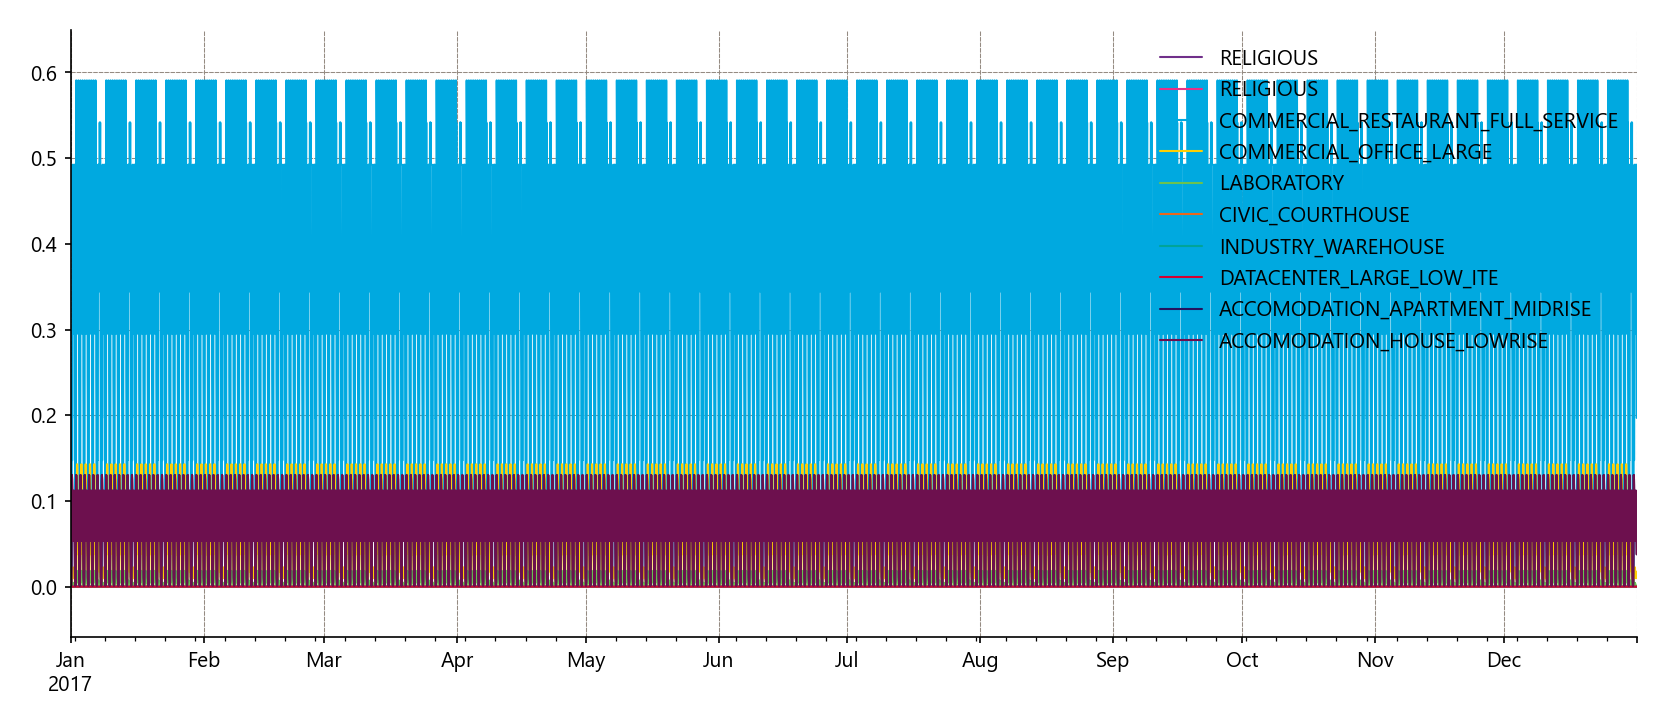

In [94]:
# typologies[0].program.profile_table(typologies[0].building_type).filter(regex="Hot Water").plot()
aa = []
for _ in range(10):
    typ = Typology.random()
    aa.append(typ.program.profile_table(typ.building_type).filter(regex="Hot Water").squeeze().rename(typ.building_type.name))
pd.concat(aa, axis=1).plot()

<Axes: >

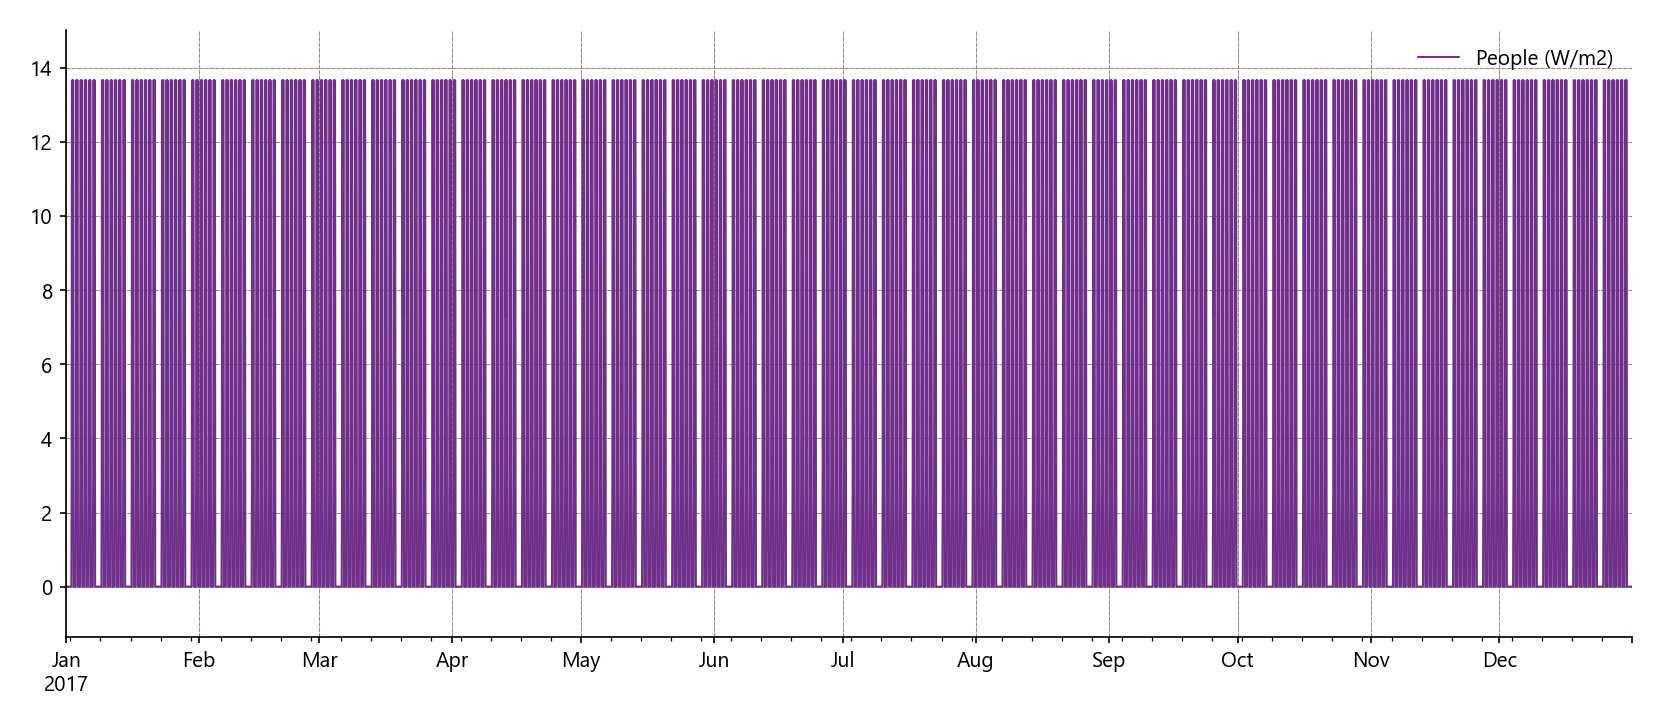

In [53]:
typologies[0].gain_people(normalised=True).plot(legend=True)

In [39]:
mp = Masterplan(
    identifier="hi",
    typologies=typologies,
    epw_file=epw_file
)
results = mp.simulate()

In [41]:
results.columns.get_level_values(1).unique()

Index(['Heating (kWh)', 'Solar (kWh)', 'Electric Equipment (kWh)',
       'Lighting (kWh)', 'People (kWh)', 'Infiltration (kWh)',
       'Mechanical Ventilation (kWh)', 'Opaque Conduction (kWh)',
       'Window Conduction (kWh)', 'Cooling (kWh)', 'Storage (kWh)',
       'Site Outdoor Air Drybulb Temperature (C)',
       'Zone Ideal Loads Zone Total Heating Energy Intensity (kWh)',
       'Zone Ideal Loads Zone Total Cooling Energy Intensity (kWh)',
       'Zone Mechanical Ventilation Current Density Volume Flow Rate (m3/s)',
       'Zone Electric Equipment Electricity Energy Intensity (kWh)',
       'Zone People Total Heating Energy Intensity (kWh)',
       'Zone Ideal Loads Supply Air Total Cooling Energy Intensity (kWh)',
       'Zone Lights Total Heating Energy Intensity (kWh)',
       'Zone Windows Total Transmitted Solar Radiation Energy Intensity (kWh)',
       'Zone Thermostat Cooling Setpoint Temperature (C)',
       'Zone Infiltration Total Heat Loss Energy Intensity (kWh)',
 

In [28]:
Program(building_type="BuildingType.COMMERCIAL_OFFICE_MEDIUM").dict()

ValidationError: 2 validation errors for Program
building_type
  value is not a valid enumeration member; permitted: 'HighriseApartment', 'ConcertHall', 'MidriseApartment', 'LargeHotel', 'SmallHotel', 'ResidentialLowRise', 'Courthouse', 'Library', 'LargeOffice', 'MediumOffice', 'SmallOffice', 'FullServiceRestaurant', 'QuickServiceRestaurant', 'Retail', 'StripMall', 'SuperMarket', 'LargeDataCenterHighITE', 'LargeDataCenterLowITE', 'SmallDataCenterHighITE', 'SmallDataCenterLowITE', 'College', 'PrimarySchool', 'SecondarySchool', 'Hospital', 'Outpatient', 'LightIndustry', 'Warehouse', 'Laboratory', 'ParkingBasement', 'PhysicalFitnessEvents', 'PhysicalFitnessExercise', 'Religious' (type=type_error.enum; enum_values=[<BuildingType.ACCOMODATION_APARTMENT_HIGHRISE: 'HighriseApartment'>, <BuildingType.CIVIC_CONCERT_HALL: 'ConcertHall'>, <BuildingType.ACCOMODATION_APARTMENT_MIDRISE: 'MidriseApartment'>, <BuildingType.ACCOMODATION_HOTEL_LARGE: 'LargeHotel'>, <BuildingType.ACCOMODATION_HOTEL_SMALL

In [7]:
df = Typology(identifier="Office").results(
    epw=EPW(r"C:\Users\tgerrish\Documents\GitHub\BHoM\LadyBugTools_Prototypes\LadyBugTools_Prototype_Engine\Python\MasterplanEnergyDemand\masterplanenergydemand\test\test.epw"),
    save=True
)
df.head()

masterplanenergydemand - INFO - Results for Office already exist.


,Heating (kWh/m2),Solar (kWh/m2),Service Hot Water (kWh/m2),Electric Equipment (kWh/m2),Lighting (kWh/m2),People (kWh/m2),Infiltration (kWh/m2),Mechanical Ventilation (kWh/m2),Opaque Conduction (kWh/m2),Window Conduction (kWh/m2),...,Zone Thermostat Heating Setpoint Temperature (C),Zone Ideal Loads Supply Air Total Cooling Energy Intensity (kWh/m2),Zone Thermostat Cooling Setpoint Temperature (C),Water Heater Electricity Energy Intensity (kWh/m2),Zone People Total Heating Energy Intensity (kWh/m2),Zone Ideal Loads Supply Air Total Heating Energy Intensity (kWh/m2),Zone Electric Equipment Total Heating Energy Intensity (kWh/m2),Water Use Equipment Zone Latent Gain Energy Intensity (kWh/m2),Zone Mean Air Temperature (C),Site Outdoor Air Drybulb Temperature (C)
2017-01-01 00:00:00,0.031861,0.0,0.0,0.0,0.0,0.0,-0.024077,-0.005702,-0.009486,-0.005117,...,18.19239,2.507434,62.842466,20.984508,0.0,134.365768,0.0,1.898932,19.94688,10.236143
2017-01-01 01:00:00,0.045868,0.0,0.0,0.0,0.0,0.0,-0.029436,-0.006693,-0.014245,-0.007130,...,18.19239,2.507434,62.842466,20.984508,0.0,134.365768,0.0,1.898932,19.94688,10.236143
2017-01-01 02:00:00,0.050163,0.0,0.0,0.0,0.0,0.0,-0.029677,-0.006564,-0.015352,-0.007690,...,18.19239,2.507434,62.842466,20.984508,0.0,134.365768,0.0,1.898932,19.94688,10.236143
2017-01-01 03:00:00,0.053208,0.0,0.0,0.0,0.0,0.0,-0.030757,-0.006745,-0.016204,-0.008092,...,18.19239,2.507434,62.842466,20.984508,0.0,134.365768,0.0,1.898932,19.94688,10.236143
2017-01-01 04:00:00,0.054459,0.0,0.0,0.0,0.0,0.0,-0.031428,-0.006863,-0.016055,-0.008202,...,18.19239,2.507434,62.842466,20.984508,0.0,134.365768,0.0,1.898932,19.94688,10.236143


In [117]:
df

,Heating (kWh),Solar (kWh),Service Hot Water (kWh),Electric Equipment (kWh),Lighting (kWh),People (kWh),Infiltration (kWh),Mechanical Ventilation (kWh),Opaque Conduction (kWh),Window Conduction (kWh),...,Zone Mean Radiant Temperature (C),Zone Lights Total Heating Energy (kWh),Zone Thermostat Cooling Setpoint Temperature (C),Pump Electricity Energy (kWh),Water Use Equipment Zone Sensible Heat Gain Energy (kWh),Water Use Equipment Zone Latent Gain Energy (kWh),Zone Ideal Loads Supply Air Total Heating Energy (kWh),Zone People Total Heating Energy (kWh),Surface Window Heat Loss Energy (kWh),Zone Thermostat Heating Setpoint Temperature (C)
2017-01-01 00:00:00,3.186130,0.0,0.0,0.0,0.0,0.0,-2.407654,-0.570179,-0.948580,-0.511657,...,19.927364,0.0,62.842466,0.274615,47.283545,189.893206,13436.576822,0.0,867.588044,18.19239
2017-01-01 01:00:00,4.586796,0.0,0.0,0.0,0.0,0.0,-2.943641,-0.669292,-1.424461,-0.713030,...,19.927364,0.0,62.842466,0.274615,47.283545,189.893206,13436.576822,0.0,867.588044,18.19239
2017-01-01 02:00:00,5.016265,0.0,0.0,0.0,0.0,0.0,-2.967658,-0.656363,-1.535234,-0.768997,...,19.927364,0.0,62.842466,0.274615,47.283545,189.893206,13436.576822,0.0,867.588044,18.19239
2017-01-01 03:00:00,5.320788,0.0,0.0,0.0,0.0,0.0,-3.075749,-0.674486,-1.620365,-0.809201,...,19.927364,0.0,62.842466,0.274615,47.283545,189.893206,13436.576822,0.0,867.588044,18.19239
2017-01-01 04:00:00,5.445892,0.0,0.0,0.0,0.0,0.0,-3.142828,-0.686281,-1.605528,-0.820169,...,19.927364,0.0,62.842466,0.274615,47.283545,189.893206,13436.576822,0.0,867.588044,18.19239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-31 19:00:00,2.393459,0.0,0.0,0.0,0.0,0.0,-1.527811,-0.341471,-0.735872,-0.408885,...,19.927364,0.0,62.842466,0.274615,47.283545,189.893206,13436.576822,0.0,867.588044,18.19239
2017-12-31 20:00:00,2.519703,0.0,0.0,0.0,0.0,0.0,-1.591055,-0.356055,-0.800015,-0.432791,...,19.927364,0.0,62.842466,0.274615,47.283545,189.893206,13436.576822,0.0,867.588044,18.19239
2017-12-31 21:00:00,2.669444,0.0,0.0,0.0,0.0,0.0,-1.679393,-0.376267,-0.845830,-0.455325,...,19.927364,0.0,62.842466,0.274615,47.283545,189.893206,13436.576822,0.0,867.588044,18.19239
2017-12-31 22:00:00,2.897029,0.0,0.0,0.0,0.0,0.0,-1.842002,-0.412412,-0.881665,-0.483447,...,19.927364,0.0,62.842466,0.274615,47.283545,189.893206,13436.576822,0.0,867.588044,18.19239


In [5]:
# mped.system.System()
# mped.fabric.Fabric()
# mped.form.Form()
# mped.program.Program()

In [26]:
mped.enums

AttributeError: module 'masterplanenergydemand' has no attribute 'enums'

In [26]:

json_str = mped.program.Program().json()
mped.program.Program.parse_raw(json_str)

mped.program.Program().get_program(mped.enums.BuildingType.EDUCATION_COLLEGE)

Program Type: Custom Program

In [2]:
# frm = mped.TypologyForm(
#     average_footprint_area=100, 
#     average_num_floors=12, 
#     glazing_ratio=[0.1, 0.4, 0, 0, 0, 0, 0, 0], 
#     rotation=0, 
#     terrain=mped.form.TerrainType.OCEAN, 
#     skylight_ratio=0.0
# ).base_model().to_hbjson()

frm = mped.TypologyForm.from_defaults(mped.form.BuildingType.ACCOMODATION_HOTEL_LARGE)
# mped.TypologyForm()
# frm.base_model()
# mped.enums.default_context_shade_distance(mped.TerrainType.CITY)

masterplanenergydemand - INFO - > using "average_footprint_area" of 2200.0m2 for BuildingType.ACCOMODATION_HOTEL_LARGE
masterplanenergydemand - INFO - > using "average_num_floors" of 5 for BuildingType.ACCOMODATION_HOTEL_LARGE
masterplanenergydemand - INFO - > using "average_floor_height" of 3.8m for BuildingType.ACCOMODATION_HOTEL_LARGE
masterplanenergydemand - INFO - > using "glazing_ratio" of 0.2 for BuildingType.ACCOMODATION_HOTEL_LARGE
masterplanenergydemand - INFO - > no "rotation" provided, using default value of 0°
masterplanenergydemand - INFO - > no "terrain" provided, using default value of TerrainType.URBAN
masterplanenergydemand - INFO - > no "skylight_ratio" provided, using default value of 0


In [12]:
mped.fabric.Fabric()

Fabric(wall_u_value=[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], wall_sri=35, floor_u_value=0.5, roof_u_value=0.5, window_u_value=[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], window_shgc=[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], skylight_u_value=0.5, skylight_shgc=0.5, roof_sri=35)

In [4]:
from typing import Any

def number_validator(value: float | int, prop_name: str, gt: float = None, ge: float = None, lt: float = None, le: float = None) -> None:
    if not isinstance(value, (float, int)):
        raise ValueError(f"{prop_name} must be a number")
    if gt is not None and ge is not None:
        raise ValueError("Both 'gt' and 'ge' cannot be provided.")
    if lt is not None and le is not None:
        raise ValueError("Both 'lt' and 'le' cannot be provided.")
    if gt is not None and value <= gt:
        raise ValueError(f"{prop_name} must be greater than {gt}")
    if ge is not None and value < ge:
        raise ValueError(f"{prop_name} must be greater than or equal to {ge}")
    if lt is not None and value >= lt:
        raise ValueError(f"{prop_name} must be less than {lt}")
    if le is not None and value > le:
        raise ValueError(f"{prop_name} must be less than or equal to {le}")

def list_of_nums_validator(value: Any, prop_name: str, length: int, ge: float = None, le: float = None, gt: float = None, lt: float = None) -> None:
    if not isinstance(value, (list, tuple)):
        raise ValueError(f"{prop_name} must be a list or tuple")
    if len(value) != length:
        raise ValueError(f"{prop_name} must have {length} items")
    for i in value:
        number_validator(i, prop_name, gt, ge, lt, le)


list_of_nums_validator([0, 1, 2, 3, 11], "XYZ", length=5, ge=0, lt=11.99)


In [9]:
for building_type in BuildingType:
    print(building_type, default_construction_type(building_type))

BuildingType.ACCOMODATION_APARTMENT_HIGHRISE ConstructionType.MASS
BuildingType.ACCOMODATION_APARTMENT_MIDRISE ConstructionType.MASS
BuildingType.ACCOMODATION_HOTEL_LARGE ConstructionType.MASS
BuildingType.ACCOMODATION_HOTEL_SMALL ConstructionType.MASS
BuildingType.ACCOMODATION_HOUSE_LOWRISE ConstructionType.WOOD_FRAMED
BuildingType.CIVIC_CONCERT_HALL ConstructionType.STEEL_FRAMED
BuildingType.CIVIC_COURTHOUSE ConstructionType.MASS
BuildingType.CIVIC_LIBRARY ConstructionType.MASS
BuildingType.COMMERCIAL_OFFICE_LARGE ConstructionType.MASS
BuildingType.COMMERCIAL_OFFICE_MEDIUM ConstructionType.MASS
BuildingType.COMMERCIAL_OFFICE_SMALL ConstructionType.STEEL_FRAMED
BuildingType.COMMERCIAL_RESTAURANT_FULL_SERVICE ConstructionType.STEEL_FRAMED
BuildingType.COMMERCIAL_RESTAURANT_QUICK_SERVICE ConstructionType.STEEL_FRAMED
BuildingType.COMMERCIAL_RETAIL ConstructionType.STEEL_FRAMED
BuildingType.COMMERCIAL_STRIP_MALL ConstructionType.MASS
BuildingType.COMMERCIAL_SUPERMARKET ConstructionType.S

In [ ]:


# from masterplanenergydemand.mped import *
# from masterplanenergydemand.utilities import *
# from masterplanenergydemand.programs.ncm import load_access_tables

In [ ]:
from ladybug.climatezone import ashrae_climate_zone, HourlyContinuousCollection

xx = []
heating_cops = []
cooling_eers = []
fan_powers = []
pump_powers = []
sens_hres = []
lat_hres = []
for bt in BuildingType:
    for v in Vintage:
        for clim in range(8):
            clim += 1
            xx.append([bt.name, v.name, clim])
            
            # get the cooling eer by interpolating between min/max
            cooling_eers.append(np.interp((vintage_val_map[v.name]) * (climate_val_map[clim]), [0, 1], [2.5, 10]))

            # get the heating cop by interpolating between min/max
            heating_cops.append(np.interp((vintage_val_map[v.name]) * (1 - climate_val_map[clim]), [0, 1], [1, 4]))

            # get fan power mapping, 
            fan_powers.append(np.interp((1 - vintage_val_map[v.name]) * (fp_map[bt.name]), [0, 1], [1.2, 2.5]))

            # get HR effectivenes
            sens_hres.append(np.interp((vintage_val_map[v.name]), [0, 1], [0, 0.4]))
            lat_hres.append(np.interp((vintage_val_map[v.name]), [0, 1], [0, 0.2]))
            
rr = pd.concat([
    pd.DataFrame(xx), 
    pd.Series(cooling_eers, name="cooling_eer"), 
    pd.Series(heating_cops, name="heating_cop"), 
    pd.Series(fan_powers, name="fan_power"), 
    pd.Series([0.35] * len(xx), name="pump_power"), 
    pd.Series(sens_hres, name="sensible_heat_recovery_effectiveness"),
    pd.Series(lat_hres, name="latent_heat_recovery_effectiveness")
], axis=1)
# rr["fan_power"].groupby([rr[0], rr[1]]).mean().unstack()
# rr

rr[["cooling_eer", "heating_cop", "fan_power", "pump_power", "sensible_heat_recovery_effectiveness", "latent_heat_recovery_effectiveness"]].to_clipboard(excel=True)
rr